<a href="https://colab.research.google.com/github/Valdan-D/remorse/blob/main/eda_Danilo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REMORSE — Exploratory Data Analysis
**Reptilian Evaluation of Mesozoic Origins: Retrospective Study on Extinction**

Questo notebook esplora i due dataset fossili della Paleobiology Database (PBDB):
- `dinos.csv` — occorrenze fossili di Dinosauria
- `plants.csv` — occorrenze fossili di Plantae (Mesozoico)

Obiettivo: capire la qualità dei dati, identificare anomalie e prendere decisioni informate sulle trasformazioni da applicare nella pipeline ETL.

## 0. Setup

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Librerie caricate.')

Librerie caricate.


## 1. Caricamento dei dataset

In [20]:
dinos = pd.read_csv('data/raw/dinos.csv', low_memory=False)
plants = pd.read_csv('data/raw/plants.csv', low_memory=False)

print(f'dinos.csv  → {dinos.shape[0]:,} righe, {dinos.shape[1]} colonne')
print(f'plants.csv → {plants.shape[0]:,} righe, {plants.shape[1]} colonne')

dinos.csv  → 37,790 righe, 38 colonne
plants.csv → 57,394 righe, 38 colonne


## 2. Struttura dei dataset

In [21]:
print('=== DINOS ===')
dinos.info()

=== DINOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37790 entries, 0 to 37789
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     37790 non-null  int64  
 1   record_type       37790 non-null  object 
 2   reid_no           4154 non-null   float64
 3   flags             3417 non-null   object 
 4   collection_no     37790 non-null  int64  
 5   identified_name   37790 non-null  object 
 6   identified_rank   37790 non-null  object 
 7   identified_no     12703 non-null  float64
 8   difference        3889 non-null   object 
 9   accepted_name     37790 non-null  object 
 10  accepted_attr     37748 non-null  object 
 11  accepted_rank     37790 non-null  object 
 12  accepted_no       37790 non-null  int64  
 13  early_interval    37790 non-null  object 
 14  late_interval     8675 non-null   object 
 15  max_ma            37790 non-null  float64
 16  min_ma            37790 no

In [22]:
print('=== PLANTS ===')
plants.info()

=== PLANTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     57394 non-null  int64  
 1   record_type       57394 non-null  object 
 2   reid_no           167 non-null    float64
 3   flags             14503 non-null  object 
 4   collection_no     57394 non-null  int64  
 5   identified_name   57394 non-null  object 
 6   identified_rank   57394 non-null  object 
 7   identified_no     3597 non-null   float64
 8   difference        11512 non-null  object 
 9   accepted_name     57394 non-null  object 
 10  accepted_attr     56253 non-null  object 
 11  accepted_rank     57394 non-null  object 
 12  accepted_no       57394 non-null  int64  
 13  early_interval    57394 non-null  object 
 14  late_interval     19454 non-null  object 
 15  max_ma            57394 non-null  float64
 16  min_ma            57394 n

In [23]:
# Colonne presenti in entrambi i dataset
comuni = set(dinos.columns) & set(plants.columns)
solo_dinos = set(dinos.columns) - set(plants.columns)
solo_plants = set(plants.columns) - set(dinos.columns)

print(f'Colonne comuni:      {len(comuni)}')
print(f'Solo in dinos:       {len(solo_dinos)} → {solo_dinos}')
print(f'Solo in plants:      {len(solo_plants)} → {solo_plants}')

Colonne comuni:      38
Solo in dinos:       0 → set()
Solo in plants:      0 → set()


## 3. Analisi dei valori nulli

In [24]:
def null_report(df, name):
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    print(f'\n=== {name} — colonne con valori nulli ===')
    print(null_pct.to_string())

null_report(dinos, 'DINOS')
null_report(plants, 'PLANTS')


=== DINOS — colonne con valori nulli ===
flags              90.96
difference         89.71
reid_no            89.01
member             80.93
altitude_unit      77.30
altitude_value     77.06
late_interval      77.04
geological_group   72.61
identified_no      66.39
county             50.44
formation          37.97
genus              37.66
family             23.08
geogcomments       20.86
order              19.53
geogscale          17.54
state              16.72
latlng_basis        4.26
cx_int_no           0.16
accepted_attr       0.11
cc                  0.04

=== PLANTS — colonne con valori nulli ===
reid_no            99.71
identified_no      93.73
altitude_unit      92.09
altitude_value     89.87
member             89.10
geological_group   86.21
county             81.87
difference         79.94
flags              74.73
late_interval      66.10
geogscale          52.59
geogcomments       50.98
state              35.28
formation          22.55
latlng_basis        7.23
genus          

In [25]:
# Percentuale di record con coordinate valide
dinos_coord = dinos[['lat', 'lng']].dropna()
plants_coord = plants[['lat', 'lng']].dropna()

print(f'Dinos con coordinate valide:  {len(dinos_coord):,} ({len(dinos_coord)/len(dinos)*100:.1f}%)')
print(f'Plants con coordinate valide: {len(plants_coord):,} ({len(plants_coord)/len(plants)*100:.1f}%)')

Dinos con coordinate valide:  37,790 (100.0%)
Plants con coordinate valide: 57,394 (100.0%)


## 4. Duplicati

In [26]:
print(f'Duplicati in dinos:  {dinos.duplicated().sum()}')
print(f'Duplicati in plants: {plants.duplicated().sum()}')

# Verifica unicità di occurrence_no
print(f'\noccurrence_no univoci in dinos:  {dinos["occurrence_no"].nunique():,} / {len(dinos):,}')
print(f'occurrence_no univoci in plants: {plants["occurrence_no"].nunique():,} / {len(plants):,}')

Duplicati in dinos:  0
Duplicati in plants: 0

occurrence_no univoci in dinos:  37,790 / 37,790
occurrence_no univoci in plants: 57,394 / 57,394


## 5. Distribuzione per periodo geologico

In [27]:
print('=== DINOS — early_interval (top 20) ===')
print(dinos['early_interval'].value_counts().head(20))

=== DINOS — early_interval (top 20) ===
early_interval
Holocene               5409
Late Pleistocene       4772
Late Campanian         2619
Late Maastrichtian     1511
Maastrichtian          1387
Kimmeridgian           1109
Middle Campanian        955
Aptian                  955
Hettangian              800
Early Maastrichtian     696
Campanian               637
Lancian                 589
Late Kimmeridgian       558
Middle Pleistocene      541
Norian                  522
Late Barremian          490
Pleistocene             486
Early Cenomanian        471
Rancholabrean           437
Tithonian               435
Name: count, dtype: int64


In [28]:
print('=== PLANTS — early_interval (top 20) ===')
print(plants['early_interval'].value_counts().head(20))

=== PLANTS — early_interval (top 20) ===
early_interval
Late Jurassic         3395
Maastrichtian         3038
Albian                2846
Carnian               2510
Middle Jurassic       2284
Late Aptian           2238
Early Jurassic        2126
Aptian                1968
Norian                1957
Aalenian              1459
Early Albian          1445
Lancian               1421
Cenomanian            1398
Late Albian           1251
Bajocian              1202
Bathonian             1199
Barremian             1082
Late Triassic         1067
Late Maastrichtian    1060
Pliensbachian         1037
Name: count, dtype: int64


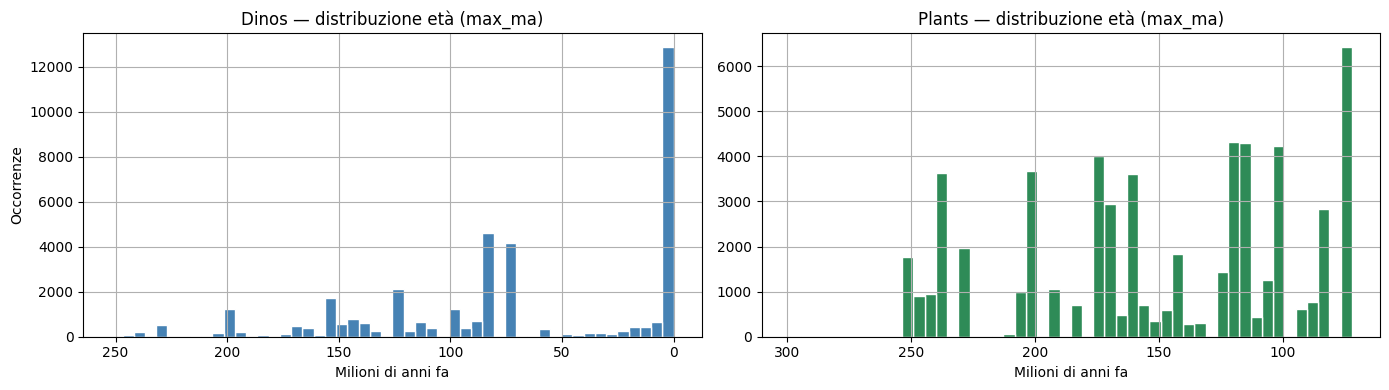

In [29]:
# Distribuzione per era (max_ma come proxy)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dinos['max_ma'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Dinos — distribuzione età (max_ma)')
axes[0].set_xlabel('Milioni di anni fa')
axes[0].set_ylabel('Occorrenze')
axes[0].invert_xaxis()

plants['max_ma'].dropna().hist(bins=50, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Plants — distribuzione età (max_ma)')
axes[1].set_xlabel('Milioni di anni fa')
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

## 6. Distribuzione geografica

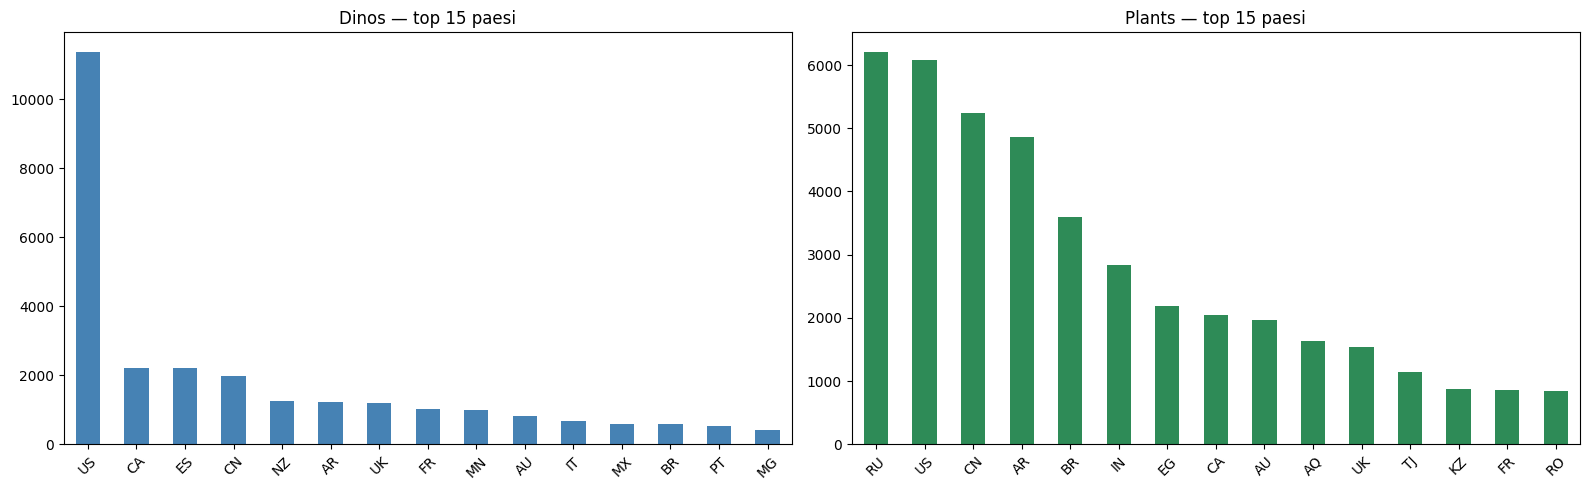

In [30]:
# Top 15 paesi per numero di ritrovamenti
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dinos['cc'].value_counts().head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Dinos — top 15 paesi')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

plants['cc'].value_counts().head(15).plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Plants — top 15 paesi')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Classificazione tassonomica

In [31]:
print('=== DINOS — classi più frequenti ===')
print(dinos['class'].value_counts().head(10))

print('\n=== DINOS — Aves nel dataset ===')
aves = dinos[dinos['class'] == 'Aves']
print(f'Record Aves: {len(aves):,} ({len(aves)/len(dinos)*100:.1f}%)')

=== DINOS — classi più frequenti ===
class
Aves            15173
Reptilia        11164
Ornithischia     7058
Saurischia       4395
Name: count, dtype: int64

=== DINOS — Aves nel dataset ===
Record Aves: 15,173 (40.2%)


In [32]:
print('=== PLANTS — phylum più frequenti ===')
print(plants['phylum'].value_counts().head(10))

=== PLANTS — phylum più frequenti ===
phylum
Pteridophyta           16141
Gymnospermae            8378
Angiospermae            7308
Ginkgophyta             4648
Equisetophyta           3357
Cycadophyta             3009
NO_PHYLUM_SPECIFIED     2663
Chlorophyta             1787
Spermatophyta           1679
Lycopodiophyta          1487
Name: count, dtype: int64


## 8. Statistiche descrittive su max_ma / min_ma

In [33]:
for name, df in [('DINOS', dinos), ('PLANTS', plants)]:
    print(f'\n=== {name} ===')
    print(df[['max_ma', 'min_ma']].describe())


=== DINOS ===
        max_ma   min_ma
count 37790.00 37790.00
mean     71.01    64.52
std      65.82    61.62
min       0.01     0.00
25%       0.13     0.01
50%      72.20    66.00
75%     121.40   100.50
max     251.90   248.10

=== PLANTS ===
        max_ma   min_ma
count 57394.00 57394.00
mean    149.34   135.53
std      55.10    53.94
min      72.20     0.00
25%     100.50    93.90
50%     143.10   121.40
75%     192.90   174.70
max     298.90   250.50


## 9. Decisioni di trasformazione

Compilare questa sezione al termine dell'EDA con le decisioni prese dal gruppo.

| Trasformazione | Decisione | Note |
|---|---|---|
| Escludere Aves | Da decidere | Vedere % in sezione 7 |
| Gestione nulli | Da decidere | Vedere sezione 3 |
| Eliminazione duplicati | Sì | Vedere sezione 4 |
| Colonna `mid_ma` | Sì | `(max_ma + min_ma) / 2` |
| Colonna `period_group` | Sì | Triassic / Jurassic / Cretaceous |
| Colonna `dataset_type` | Sì | Dinosauria / Plantae |
| Flag `has_valid_coords` | Sì | Booleano su lat/lng |
| Normalizzazione paesi | Da decidere | Vedere distribuzione in sezione 6 |